<a href="https://colab.research.google.com/github/bajatsira/optimization/blob/main/Chupanova_RK1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ВАРИАНТ №31

Даны результаты нескольких измерений:
7,4 / 11,4 / 11,2 / 8 / 11,8 / 10,5 / 6,9 / 11 / 10,1 / 12,5 / 13,9 / 8,1
1) Определите доверительную вероятность получения оценки среднего значения
измеряемой величины с точностью е = 0,5


In [9]:
import numpy as np
from scipy import stats

data = np.array([7.4, 11.4, 11.2, 8, 11.8, 10.5, 6.9, 11, 10.1, 12.5, 13.9, 8.1])
n = len(data)
mean = np.mean(data)
std_dev = np.std(data, ddof=1)  # среднеквадратичное исправленное несмещенное
df = n - 1  # Степени свободы

print(f"Среднее значение: {mean:.3f}")
print(f"Стандартное отклонение: {std_dev:.3f}")
print(f"Число измерений: {n}\n")

epsilon1 = 0.5

# Из формулы точности: epsilon = t * (s / sqrt(n)) находим t
t_value1 = (epsilon1 * np.sqrt(n)) / std_dev

# Находим вероятность P
p_value = stats.t.cdf(t_value1, df) - stats.t.cdf(-t_value1, df)

print(f"Для e = {epsilon1}:")
print(f"Доверительная вероятность P = {p_value:.4f}")


Среднее значение: 10.233
Стандартное отклонение: 2.189
Число измерений: 12

Для e = 0.5:
Доверительная вероятность P = 0.5546


2) Найдите число измерений необходимых для получения среднего значения с точностью
e = 0,25 и доверительной вероятностью Р=0,995



In [11]:

epsilon2 = 0.25
p_target = 0.995

# Так как n зависит от t-критерия, а t зависит от n,
# для простоты и надежности используем z-критерий
z_crit = stats.norm.ppf((1 + p_target) / 2)
n_needed = (z_crit * std_dev / epsilon2)**2

print(f"Для точности e = {epsilon2} и P = {p_target}:")
print(f"Необходимое число измерений: {n_needed:.2f}")
print(f"Нужно выполнить минимум {int(np.ceil(n_needed))} измерений")

Для точности e = 0.25 и P = 0.995:
Необходимое число измерений: 603.84
Нужно выполнить минимум 604 измерений


Задача Б.
В результате наблюдения было получено 99 значений признака, составляющих выборку из
генеральной совокупности. Выполните задания:
1) Найдите выборочное среднее, выборочную дисперсию, среднеквадратическое
отклонение; размах данных; максимум и минимум.
2) Оцените математическое ожидание генеральной совокупности с помощью
доверительного интервала с надёжностями 0,95; 0,99; 0,999.
3) Постройте гистограмму частот.
4) Постройте график плотности показательного распределения (pdf) с параметрами
этой выборки.
5) Постройте диаграмму размаха данных (блочная диаграмма с ограничителями -
показывает распределение данных по квартилям с выбросами).
6) Примените критерий Пирсона χ2 с уровнем значимости 0,05 для проверки гипотезы
о показательном распределении генеральной совокупности. Сделайте вывод о
принятии основной гипотезы.
102,7 120,2 93,83 100,4 95,26 98,64 84,49 99,58 123,6
107,5 113,6 97,48 84,52 93,59 94,26 94,95 95,62 86,58
62,97 26,17 83,88 24,48 44,65 75,85 34,92 35,83 127,9
77,46 37,04 76,29 84,06 139,5 45,62 49,69 56,96 74,24
60,12 42,56 62,18 52,52 84,83 78,79 43,54 95,85 57,19
81,22 30,58 51,05 25,39 57,05 120,2 72,77 67,48 138,9
44,58 182,1 47,29 67,69 57,79 46,08 28,59 63,78 80,33
59,08 36,42 53,17 68,26 27,22 64,28 60,42 30,57 32,18
85,87 61,42 73,77 56,04 78,46 88,89 68,21 84,05 69,46
82,86 38,03 79,54 62,64 48,89 71,56 24,83 39,29 96,53
85,27 127,1 61,67 60,71 67,99 67,24 74,14 52,09 45,43

1. Найдите выборочное среднее, выборочную дисперсию, среднеквадратическое отклонение; размах данных; максимум и минимум.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

raw_data = """
102.7 120.2 93.83 100.4 95.26 98.64 84.49 99.58 123.6 107.5 113.6 97.48 84.52 93.59 94.26
94.95 95.62 86.58 62.97 26.17 83.88 24.48 44.65 75.85 34.92 35.83 127.9 77.46 37.04 76.29
84.06 139.5 45.62 49.69 56.96 74.24 60.12 42.56 62.18 52.52 84.83 78.79 43.54 95.85 57.19
81.22 30.58 51.05 25.39 57.05 120.2 72.77 67.48 138.9 44.58 182.1 47.29 67.69 57.79 46.08
28.59 63.78 80.33 59.08 36.42 53.17 68.26 27.22 64.28 60.42 30.57 32.18 85.87 61.42 73.77
56.04 78.46 88.89 68.21 84.05 69.46 82.86 38.03 79.54 62.64 48.89 71.56 24.83 39.29 96.53
85.27 127.1 61.67 60.71 67.99 67.24 74.14 52.09 45.43
"""
data = np.array([float(x) for x in raw_data.split()])


mean_val = np.mean(data)
var_val = np.var(data, ddof=1)  # дисперсия
std_val = np.std(data, ddof=1)  # СКО
range_val = np.ptp(data)        # размах
min_val, max_val = np.min(data), np.max(data)

print(f"Выборочное среднее: {mean_val:.3f}")
print(f"Дисперсия: {var_val:.3f}, среднеквадратическое: {std_val:.3f}")
print(f"Размах: {range_val:.3f} (от {min_val} до {max_val})")
print(f"Минимум: {min_val}")
print(f"Максимум: {min_val}")


Выборочное среднее: 71.397
Дисперсия: 856.026, среднеквадратическое: 29.258
Размах: 157.620 (от 24.48 до 182.1)
Минимум: 24.48
Максимум: 24.48


2. Оцените математическое ожидание генеральной совокупности с помощью доверительного интервала с надёжностями 0,95; 0,99; 0,999.


In [18]:

conf_levels = [0.95, 0.99, 0.999]
print("\nДоверительные интервалы:")
for p in conf_levels:
    ci = stats.t.interval(p, df=len(data)-1, loc=mean_val, scale=stats.sem(data))
    print(f"P={p}: ({ci[0]:.3f}, {ci[1]:.3f})")


Доверительные интервалы:
P=0.95: (65.562, 77.233)
P=0.99: (63.673, 79.122)
P=0.999: (61.421, 81.373)


3. Постройте гистограмму частот.
4. Постройте график плотности показательного распределения (pdf) с параметрами этой выборки.

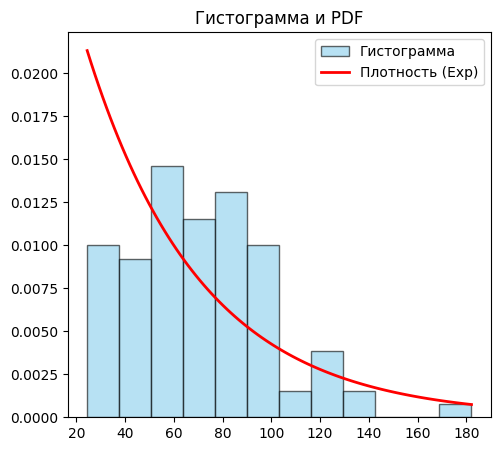

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
count, bins, ignored = plt.hist(data, bins=12, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Гистограмма')

# Плотность показательного (экспоненциального) распределения
# Параметр экспоненциального распределения λ = 1 / mean
# В scipy.stats.expon: scale = 1/λ = mean
x = np.linspace(min_val, max_val, 100)
pdf = stats.expon.pdf(x, loc=min_val, scale=mean_val - min_val) # Сдвиг loc обычно равен min
plt.plot(x, pdf, 'r-', lw=2, label='Плотность (Exp)')
plt.title("Гистограмма и PDF")
plt.legend()



5. Постройте диаграмму размаха данных (блочная диаграмма с ограничителями - показывает распределение данных по квартилям с выбросами).


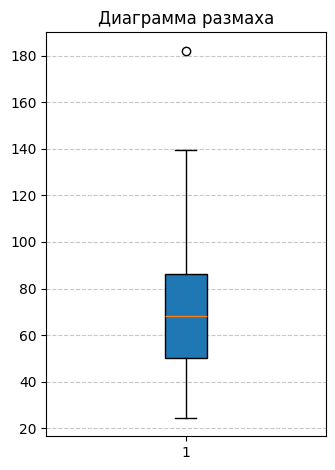

In [24]:
plt.subplot(1, 2, 2)
plt.boxplot(data, vert=True, patch_artist=True)
plt.title("Диаграмма размаха")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


6. Примените критерий Пирсона χ2 с уровнем значимости 0,05 для проверки гипотезы о показательном распределении генеральной совокупности. Сделайте вывод о принятии основной гипотезы. 102,7 120,2 93,83 100,4 95,26 98,64 84,49 99,58 123,6 107,5 113,6 97,48 84,52 93,59 94,26 94,95 95,62 86,58 62,97 26,17 83,88 24,48 44,65 75,85 34,92 35,83 127,9 77,46 37,04 76,29 84,06 139,5 45,62 49,69 56,96 74,24 60,12 42,56 62,18 52,52 84,83 78,79 43,54 95,85 57,19 81,22 30,58 51,05 25,39 57,05 120,2 72,77 67,48 138,9 44,58 182,1 47,29 67,69 57,79 46,08 28,59 63,78 80,33 59,08 36,42 53,17 68,26 27,22 64,28 60,42 30,57 32,18 85,87 61,42 73,77 56,04 78,46 88,89 68,21 84,05 69,46 82,86 38,03 79,54 62,64 48,89 71,56 24,83 39,29 96,53 85,27 127,1 61,67 60,71 67,99 67,24 74,14 52,09 45,43

In [26]:
hist, bins = np.histogram(data, bins=10)
expected = len(data) * np.diff(stats.expon.cdf(bins, scale=mean))

chi2 = np.sum((hist - expected) ** 2 / expected)
crit = stats.chi2.ppf(0.95, df=9)

print("χ2:", chi2)
print("Критическое значение критерия Пирсона χ2:", crit)

if chi2 < crit:
    print("Данные соответствуют показательному распределению")
else:
    print("Данные НЕ соответствуют показательному распределению")

χ2: 233655.29724137665
Критическое значение критерия Пирсона χ2: 16.918977604620448
Данные НЕ соответствуют показательному распределению


Задача В.
1) Получите выборку (20 значений) из столбца «среднее время пребывания в системе»
результатов эксперимента моделирования в примере Excel;


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

taskB = np.array([0.16, 0.17, 0.13, 0.18, 0.15, 0.18, 0.16, 0.17, 0.17, 0.19, 0.19, 0.17, 0.16, 0.16, 0.14, 0.16, 0.18, 0.14, 0.16, 0.18])

2) По полученным данным получите аппроксимацию распределения этого признака
(линейная интерполяция). Постройте график распределения (cdf);



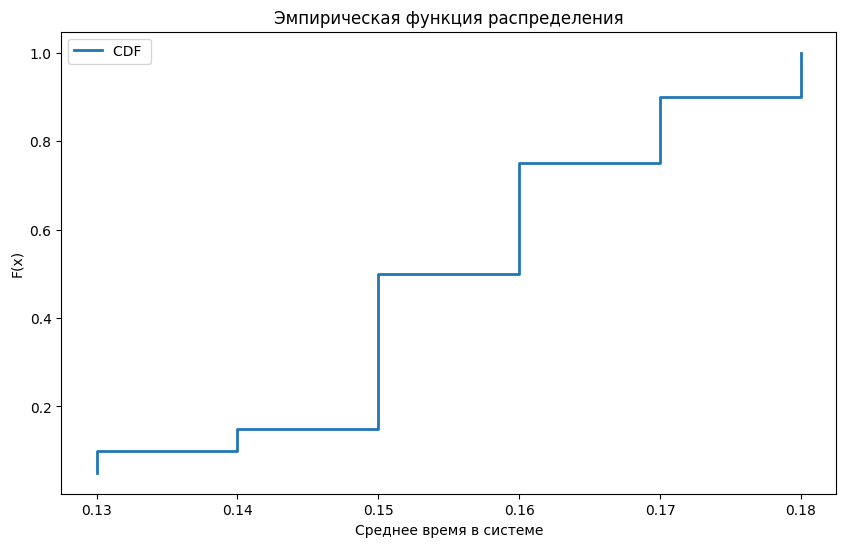

In [38]:
def plot_cdf(data, label):
    sorted_data = np.sort(data)
    y = np.arange(1, len(sorted_data) + 1) / len(sorted_data) # считаем эмпирическую cdf

    plt.step(sorted_data, y, where='post', label=f'CDF {label}', linewidth=2)
    plt.xlabel('Среднее время в системе')
    plt.ylabel('F(x)')
    plt.title('Эмпирическая функция распределения')

plt.figure(figsize=(10, 6))
plot_cdf(taskB, '')
plt.legend()
plt.show()



3) По полученному распределению найдите выборочное среднее, выборочную
дисперсию, среднеквадратическое отклонение с доверительной вероятностью 0,95;


In [43]:
mean_v = np.mean(taskB)
var_v = np.var(taskB, ddof=1)  # исправленная выборочная дисперсия
std_v = np.std(taskB, ddof=1)   # СКО
conf_level = 0.95

# довертельный интервал
n = len(taskB)
h = std_v / np.sqrt(n) * stats.t.ppf((1 + conf_level) / 2, n - 1)
conf_interval = (mean_v - h, mean_v + h)


print(f"Выборочное среднее: {mean_v:.4f}")
print(f"Выборочная дисперсия: {var_v:.6f}")
print(f"Среднеквадратическое отклонение: {std_v:.4f}")
print(f"Доверительный интервал: ({conf_interval[0]:.4f}, {conf_interval[1]:.4f})")


Выборочное среднее: 0.1560
Выборочная дисперсия: 0.000194
Среднеквадратическое отклонение: 0.0139
Доверительный интервал: (0.1495, 0.1625)


4) Сравните распределения этой выборки и данных задачи Б с помощью критерия
Колмогорова-Смирнова. Сделайте вывод о принятии основной гипотезы.


In [48]:

ks_stat, p_value = stats.ks_2samp(taskB, data)

print(f"KS-статистика: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value > alpha:
    print("Принимаем основную гипотезу, распределения не различаются")
else:
    print("Отклоняем основную гипотезу, распределения различаются")

KS-статистика: 1.0000
p-value: 0.0000
Вывод: отклоняем нулевую гипотезу. Распределения имеют статистически значимые различия.
